In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import warnings
from sklearn.exceptions import ConvergenceWarning

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.feature_selection import f_regression

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.simplefilter("ignore", DeprecationWarning)

pathfile=r'/media/nicolascatz/ssdcalcul/Projets/CRPN_DTI_AGING_DPAKNC/'
pathfile=r'D:/DATA/Projets/CRPN_DTI_AGING_DPAKNC/'

pathdata=pathfile+'data/'
pathdata_tractography=pathfile+'data/Corrected_Tractometry2025'
pathcsv=pathfile+'CSV/'
pathfig=pathfile+'figures/'
os.chdir(pathfile)

addtotitle='_03022026_woMA_for_RD_MD_AD_FA' # to specify the version of the data
metricsDTI='AD' # to specify the DTI metric to use for the analysis

#_03022026_AllSubjects
Aging_INDICES_all = pd.read_csv('Subject_preproc' + addtotitle + '.csv')

CCx_list = ['CC_1','CC_2','CC_3','CC_4','CC_5','CC_6','CC_7']
from sklearn.preprocessing import StandardScaler, MinMaxScaler,RobustScaler

scaler = RobustScaler()
DTI_all=np.zeros((42, 98, 7))  # 10 DTI metrics
DTI_all_scaled=np.zeros((42, 98, 7))  # 10 DTI metrics

for i, CC in enumerate(CCx_list):
    file_path = os.path.join(pathcsv, f'{CC}_{metricsDTI}{addtotitle}.csv')
    dfCCx = pd.read_csv(file_path, sep=",")
    DTI_all[:,:,i]=dfCCx.values  ## une variable DTI of shape subjects x nodes x n CC
    DTI_all_scaled[:,:,i]=scaler.fit_transform(dfCCx.values)  ## une variable DTI of shape subjects x nodes x n CC

 # target var

import seaborn as sns
selection=[0,42]
Aging_INDICES=Aging_INDICES_all[selection[0]:selection[1]] # only the 42 subjects  
DTI=DTI_all[selection[0]:selection[1],:,:]  # only the 42 subjects 
DTI_scaled=DTI_all_scaled[selection[0]:selection[1],:,:]  

age = Aging_INDICES['age'].values
jnd = Aging_INDICES['JND_P'].values

# DTI values 

labels = [0,1]

Aging_INDICES['JND_group'] = pd.qcut(Aging_INDICES['JND_P'], q=2, labels=labels)

age_grouped = Aging_INDICES['group_O']
jnd_grouped = Aging_INDICES['JND_group']


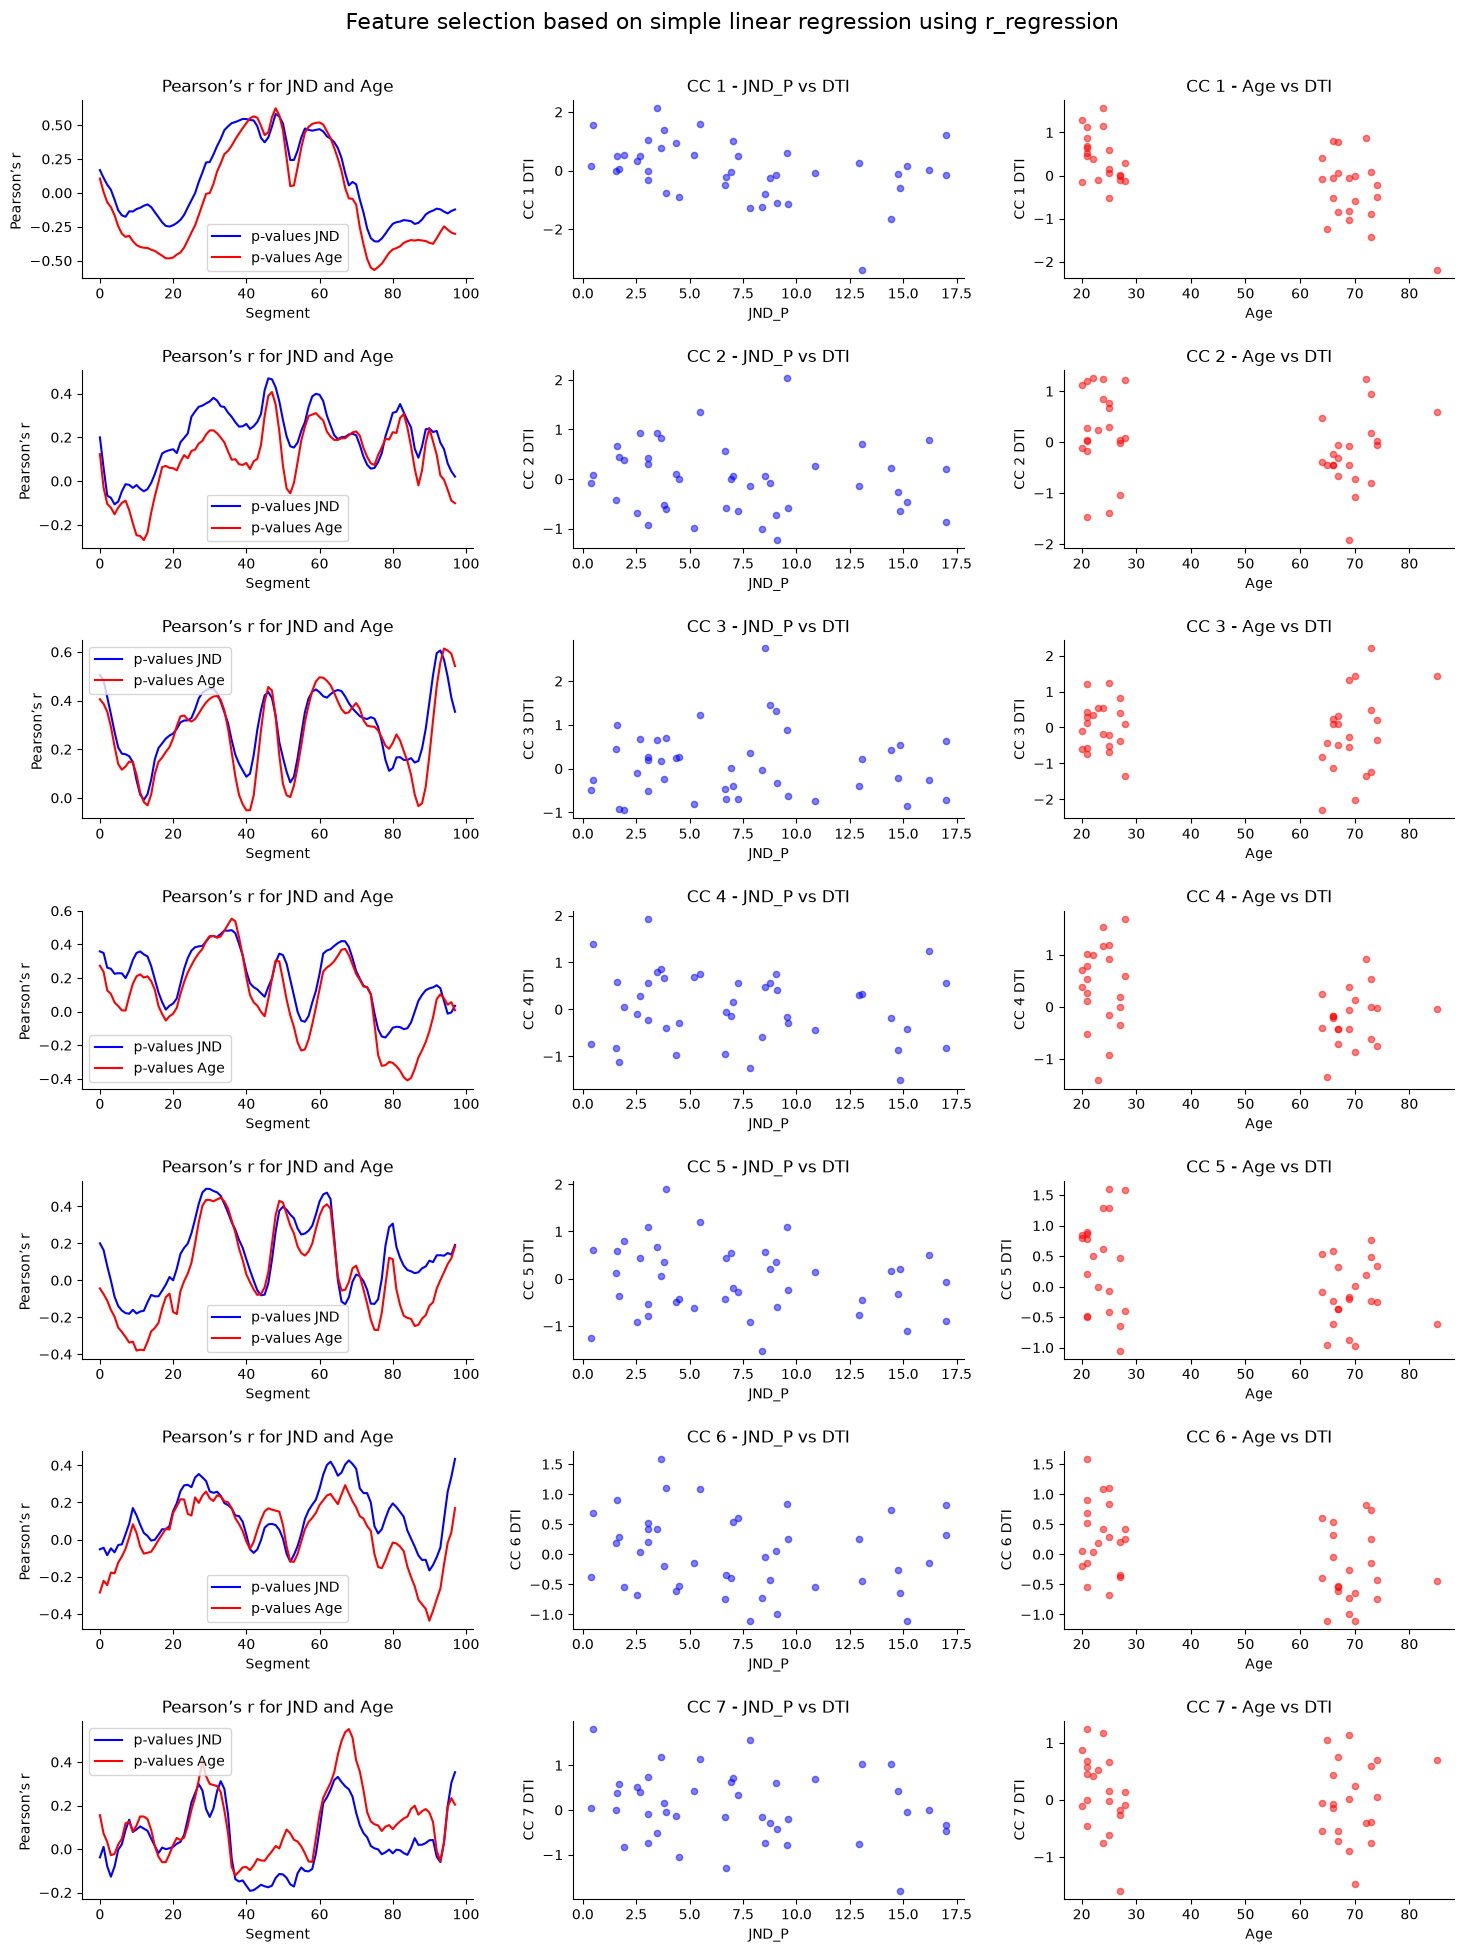

In [60]:
from sklearn.feature_selection import r_regression

####

from sklearn.feature_selection import r_regression
fig, axs = plt.subplots(nrows=7, ncols=3, figsize=(15, 20))
r_reg_best_features_jnd_cc_allCC = np.zeros((7,10), dtype=int)
r_reg_best_features_age_cc_allCC = np.zeros((7,10), dtype=int)
r_reg_age_allcc = np.zeros((7,98))
for cc in range(1,8):   
    r_reg_jnd = r_regression(DTI_scaled[:,:,cc-1], jnd)
    r_reg_age = r_regression(DTI_scaled[:,:,cc-1], age)
    r_reg_age_allcc[cc-1,:] = r_reg_age
    r_reg_best_features_jnd_cc = np.argsort(r_reg_jnd)[:97]
    r_reg_best_features_age_cc = np.argsort(r_reg_age)[:97]

    
    if metricsDTI=='FA':
        r_reg_best_features_jnd_cc_allCC[cc-1,:]= r_reg_best_features_jnd_cc[:10]
        r_reg_best_features_age_cc_allCC[cc-1,:] = r_reg_best_features_age_cc[:10]
    else: 
        r_reg_best_features_jnd_cc_allCC[cc-1,:] = r_reg_best_features_jnd_cc[-10:]
        r_reg_best_features_age_cc_allCC[cc-1,:] = r_reg_best_features_age_cc[-10:]

    axs[cc-1,0].plot(r_reg_jnd, color='blue', label='p-values JND')
    axs[cc-1,0].plot(r_reg_age, color='red', label='p-values Age')

    axs[cc-1,0].set_xlabel('Segment')
    axs[cc-1,0].set_ylabel('Pearson’s r ')  
    axs[cc-1,0].legend()
    axs[cc-1,0].set_title('Pearson’s r for JND and Age')
    axs[cc-1,0].spines['top'].set_visible(False)
    axs[cc-1,0].spines['right'].set_visible(False)

   
    featn_jnd=r_reg_best_features_jnd_cc[0]  # on prend la feature la plus significative pour JND
    featn_age=r_reg_best_features_age_cc[0]  # on prend la feature la plus significative pour Age

    axs[cc-1,1].scatter(jnd, DTI_scaled[:,featn_jnd,cc-1], color='blue', label='Données', alpha=0.5, s=20)
    axs[cc-1,2].scatter(age, DTI_scaled[:,featn_age,cc-1], color='red', label='Données', alpha=0.5, s=20)
    axs[cc-1,1].set_xlabel('JND_P')
    axs[cc-1,1].set_ylabel(f'CC {cc} DTI')
    axs[cc-1,2].set_xlabel('Age')
    axs[cc-1,2].set_ylabel(f'CC {cc} DTI')
    axs[cc-1,1].spines['top'].set_visible(False)
    axs[cc-1,2].spines['top'].set_visible(False)
    axs[cc-1,1].spines['right'].set_visible(False)
    axs[cc-1,2].spines['right'].set_visible(False)
    axs[cc-1,1].set_title(f'CC {cc} - JND_P vs DTI')
    axs[cc-1,2].set_title(f'CC {cc} - Age vs DTI')

fig.suptitle('Feature selection based on simple linear regression using r_regression\n', fontsize=16)
    
plt.tight_layout(pad=2.0) 

In [61]:

DTI_JND=pd.DataFrame([])
DTI_AGE=pd.DataFrame([])
for cc in range(1,8):
    DTI_JND_tmp=pd.DataFrame(DTI_scaled[:,r_reg_best_features_jnd_cc_allCC[cc-1],cc-1])
    DTI_JND_tmp.columns = [f'CC{cc}_{idx}' for idx in r_reg_best_features_jnd_cc_allCC[cc-1]]
    DTI_JND=pd.concat([DTI_JND, DTI_JND_tmp], axis=1)

    DTI_AGE_tmp=pd.DataFrame(DTI_scaled[:,r_reg_best_features_age_cc_allCC[cc-1],cc-1])
    DTI_AGE_tmp.columns = [f'CC{cc}_{idx}' for idx in r_reg_best_features_age_cc_allCC[cc-1]]
    DTI_AGE=pd.concat([DTI_AGE, DTI_AGE_tmp], axis=1)



In [62]:
import statsmodels.api as sm
import numpy as np
import matplotlib.pyplot as plt


def test_covariate_adjusted_association(df, outcome_col, covariate_col, predictor_col,  cc, metrics):
    """Teste l'association outcome ~ predictor en controlant pour covariate.

    - joint_model : regression multiple outcome ~ predictor + covariate (fait foi pour la p-valeur)
    - les graphiques utilisent une double residualisation (Frisch-Waugh-Lovell) :
      outcome et predictor sont chacun debarrasses de l'effet de covariate avant d'etre compares,
      ce qui rend le partial regression plot coherent avec joint_model.
    """
    data = df[[outcome_col, covariate_col, predictor_col]].dropna()

    # 1) Regression jointe : seule source valide pour le coefficient/p-value de predictor_col
    X_full = sm.add_constant(data[[predictor_col, covariate_col]])
    joint_model = sm.OLS(data[outcome_col], X_full).fit()

    # 2) Double residualisation, uniquement pour la visualisation
    X_cov = sm.add_constant(data[covariate_col])
    outcome_resid = sm.OLS(data[outcome_col], X_cov).fit().resid
    predictor_resid = sm.OLS(data[predictor_col], X_cov).fit().resid

    fig,axs = plt.subplots(1,3,figsize=(12,5))
    
    fig.suptitle(f'Partial regression plot for {outcome_col} ~ {predictor_col} adjusted for {covariate_col}\nCC {cc} - {metrics}', fontsize=14)

    axs[0].scatter(data[covariate_col], data[outcome_col], alpha=0.6, label='Raw data')
    axs[0].scatter(data[covariate_col], outcome_resid, alpha=0.6, color='red', label='Residuals (covariate effect removed)')
    axs[0].axhline(0, color='black', linestyle='--', linewidth=0.8)
    axs[0].set_xlabel(covariate_col)
    axs[0].set_ylabel(outcome_col)
    axs[0].set_title(f'{outcome_col} raw vs adjusted for {covariate_col}')
    axs[0].legend(frameon=False, loc='upper right')
    axs[0].spines['top'].set_visible(False)
    axs[0].spines['right'].set_visible(False)

    axs[1].scatter(data[covariate_col], data[predictor_col], alpha=0.6, label='Raw data')
    axs[1].scatter(data[covariate_col], predictor_resid, alpha=0.6, color='red', label='Residuals (covariate effect removed)')
    axs[1].axhline(0, color='black', linestyle='--', linewidth=0.8)
    axs[1].set_xlabel(covariate_col)
    axs[1].set_ylabel(predictor_col)
    axs[1].set_title(f'{predictor_col} raw vs adjusted for {covariate_col}')
    axs[1].spines['top'].set_visible(False)
    axs[1].spines['right'].set_visible(False)

    slope, intercept = np.polyfit(predictor_resid, outcome_resid, 1)
    line_x = np.linspace(predictor_resid.min(), predictor_resid.max(), 100)
    axs[2].scatter(predictor_resid, outcome_resid, alpha=0.6)
    axs[2].plot(line_x, slope * line_x + intercept, color='red')
    axs[2].axhline(0, color='black', linestyle='--', linewidth=0.8)
    axs[2].set_xlabel(f'{predictor_col} (adjusted for {covariate_col})')
    axs[2].set_ylabel(f'{outcome_col} (adjusted for {covariate_col})')
    axs[2].set_title('Partial regression plot (Frisch-Waugh-Lovell)')
    axs[2].spines['top'].set_visible(False)
    axs[2].spines['right'].set_visible(False)

    beta = joint_model.params[predictor_col]
    pval = joint_model.pvalues[predictor_col]
    pval_txt = 'p < 0.001' if pval < 0.001 else f'p = {pval:.3f}'
    stats_txt = f"beta = {beta:.3f}\n{pval_txt}\nR2 = {joint_model.rsquared:.3f}"
    axs[2].text(
        0.05, 0.95, stats_txt,
        transform=axs[2].transAxes,
        va='top', ha='left',
        fontsize=10,
        bbox=dict(boxstyle='round', facecolor='none', alpha=0.8, edgecolor='none')
    )
    plt.tight_layout(pad=2.0)
    plt.savefig(pathfig + f'Partial_regression_plot_CC_{cc}_{metrics}_vs_JND_adjusted_for_age.png', dpi=300)
    
    # print(f"CC {cc} :")
    # print(f"--- Regression jointe : {outcome_col} ~ {predictor_col} + {covariate_col} ---")
    # print(f"Coefficient {predictor_col} (effet partiel ajuste pour {covariate_col}) : {joint_model.params[predictor_col]:.4f}")
    # print(f"P-valeur {predictor_col} : {joint_model.pvalues[predictor_col]:.4f}")
    # print(f"Coefficient {covariate_col} : {joint_model.params[covariate_col]:.4f}")
    # print(f"P-valeur {covariate_col} : {joint_model.pvalues[covariate_col]:.4f}")
    # print(f"R-carre : {joint_model.rsquared:.3f}")

    return joint_model


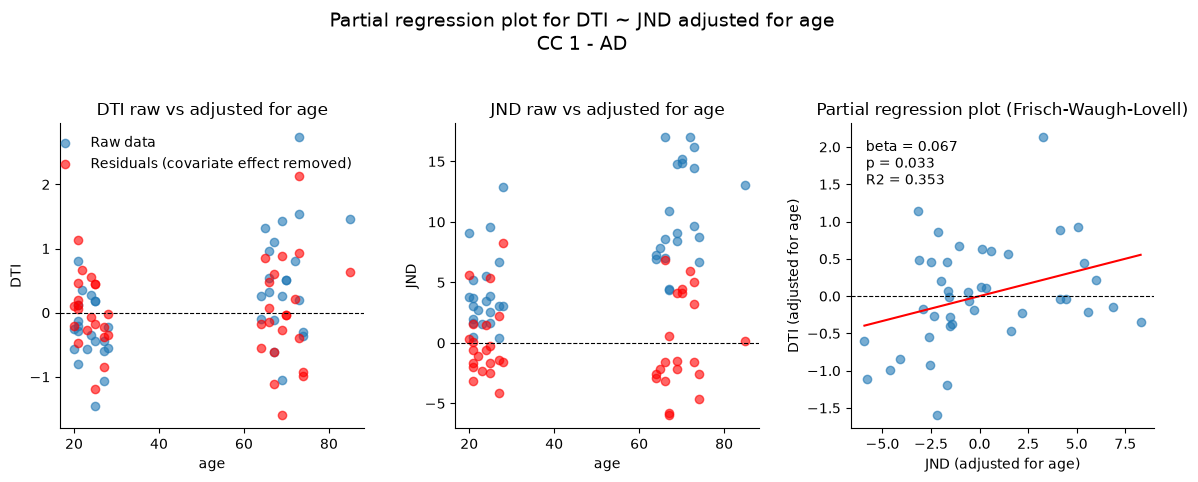

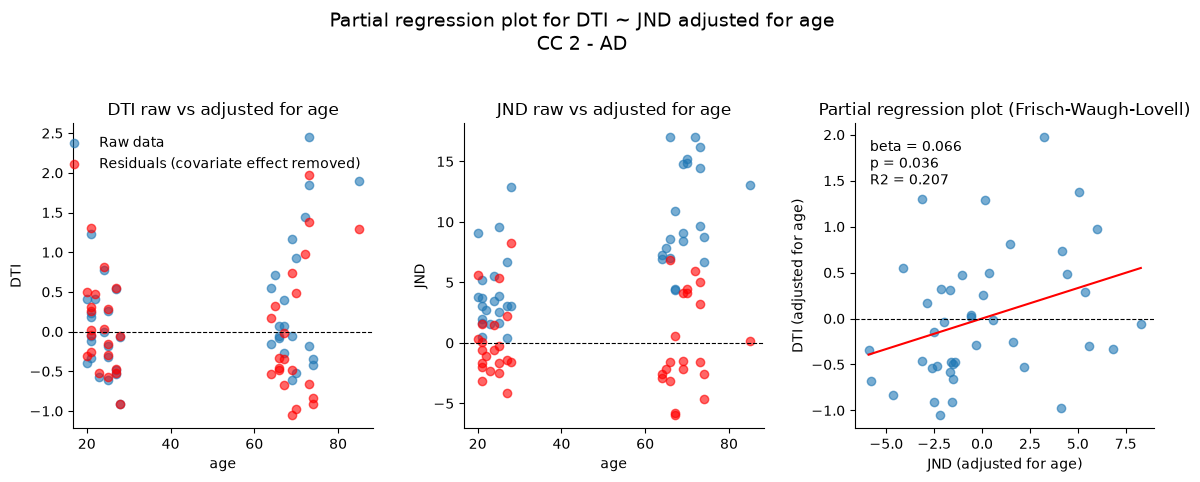

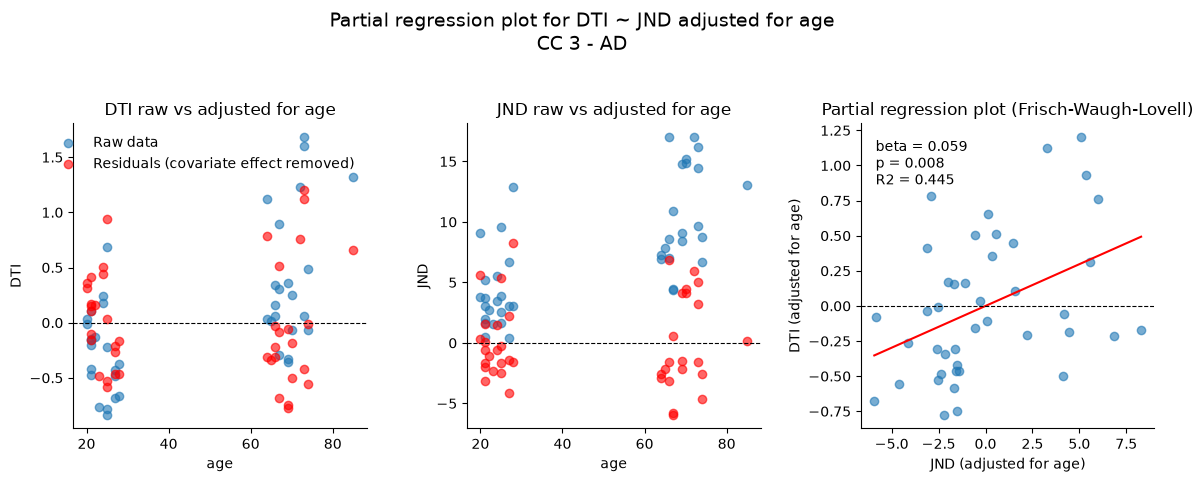

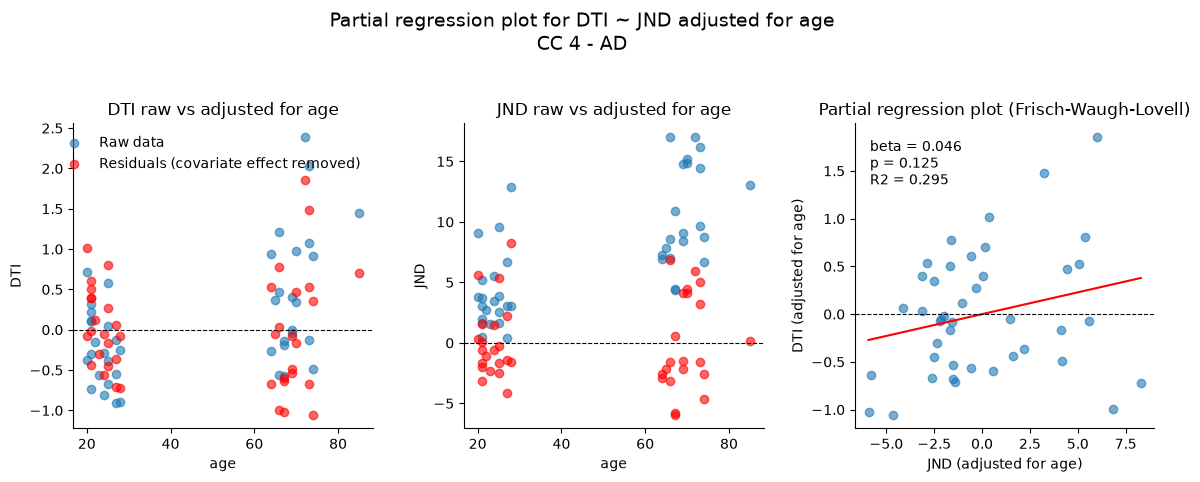

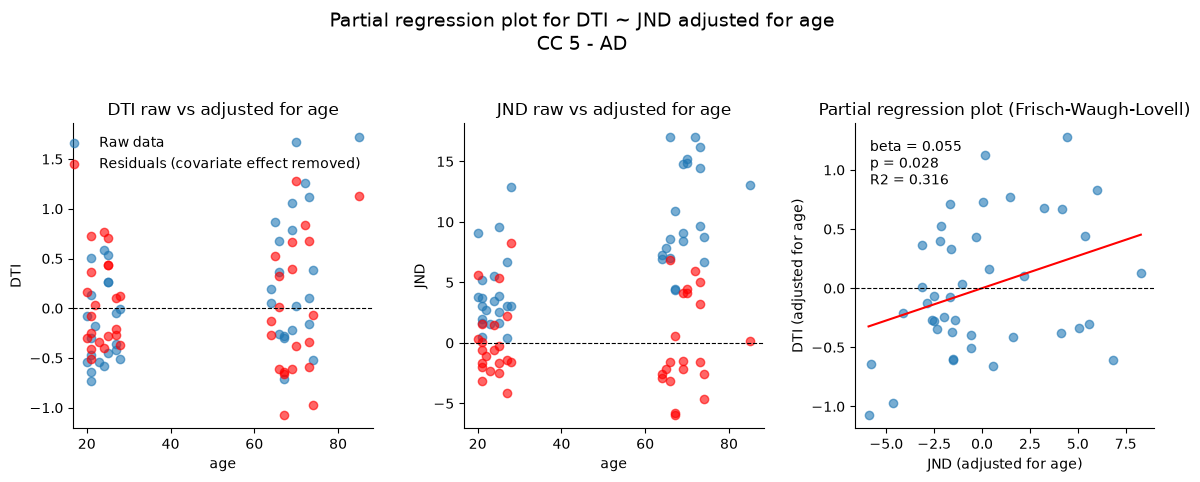

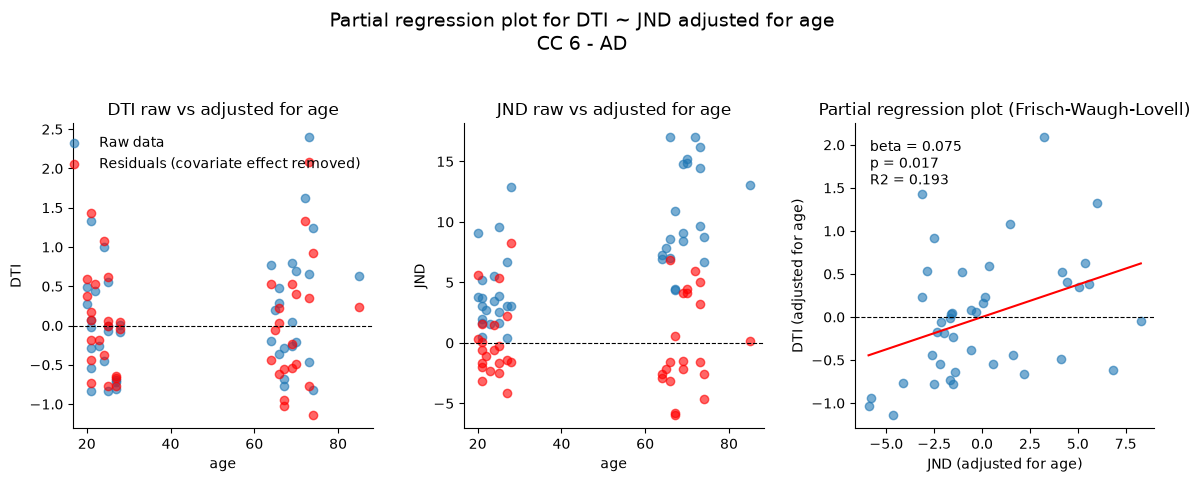

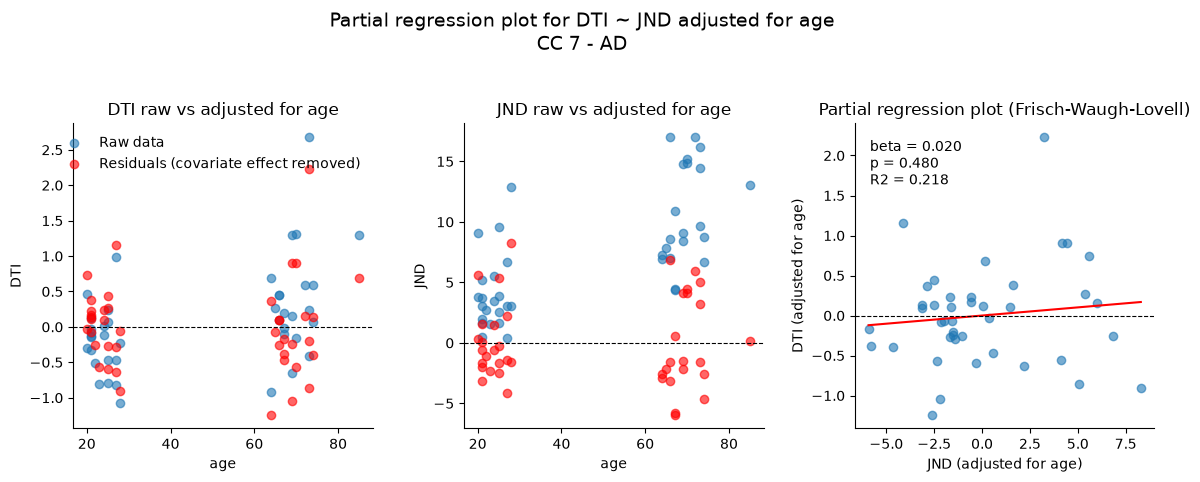

In [63]:

for cc in range(1,8):

    nseg=10
    data = DTI_JND[DTI_JND.columns[10*(cc-1):10*(cc-1)+nseg].tolist()].mean(axis=1)

    np.random.seed(42)
    n = 100
    df = pd.DataFrame({
        'DTI': data,  # Variable indépendante
        'age': age,  # Variable de contrôle
        'JND': jnd   # Variable dépendante
    })

    joint_model = test_covariate_adjusted_association(
        df,
        outcome_col='DTI',
        covariate_col='age',
        predictor_col='JND',
        cc=cc,
        metrics=metricsDTI
    )